#### Gradient Descent Implementation (Linear regression example)

In [7]:
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
### Creating a small dataset
x_train = np.array([1.0, 2.0]) # feature
y_train = np.array([300.0, 500.0]) # target

In [ ]:
### Compute the cost J(w,b) with mean squared error
def compute_cost(w, b, x, y):
    m = x.shape[0]
    cost = 0.0
    for i in range(m):
        f_wb = w * x[i] + b # linear model
        cost += (f_wb - y[i]) ** 2 # squared error
    total_cost = 1 / (2 * m) * cost # mean squared error --> divide by 2 for convenience in gradient descent
    return total_cost

In [11]:
### Compute gradient in respect to w and b by computing the partial derivatives
def compute_gradient(w, b, x, y):
    m = x.shape[0]
    dj_dw = 0.0
    dj_db = 0.0

    for i in range(m):
        f_wb = w * x[i] + b # linear model
        dj_dw_i = (f_wb -y[i]) * x[i] # partial derivative with respect to w =>slope
        dj_db_i = (f_wb - y[i]) # partial derivative with respect to b => intercept
        dj_dw += dj_dw_i
        dj_db += dj_db_i
    dj_dw = dj_dw / m # average over all examples
    dj_db = dj_db / m # average over all examples
    return dj_dw, dj_db

In [12]:
### Imlementing gradient descent
def gradient_descent(x, y, w_in, b_in, alpha, num_iters):
    J_history = []
    param_history = []
    b = b_in
    w = w_in

    for i in range(num_iters):
        dj_dw, dj_db = compute_gradient(w, b, x, y) # compute the gradient
        w = w - alpha * dj_dw # update w
        b = b - alpha * dj_db # update b

        if i < 100000: # prevent resource exhaustion
            J_history.append(compute_cost(w, b, x, y)) # compute cost for current iteration and save it
            param_history.append((w, b)) # save parameters for current iteration
    return w, b, J_history, param_history

In [ ]:
### Run gradient descent for our mini-dataset
params = gradient_descent(x_train, y_train, w_in=0.0, b_in=0.0, alpha=0.1, num_iters=100000)
print(f"w = {params[0]}, b = {params[1]}, cost = {params[2][-1].round(2)}")

w = 199.9999999999991, b = 100.00000000000144, cost = 0.0


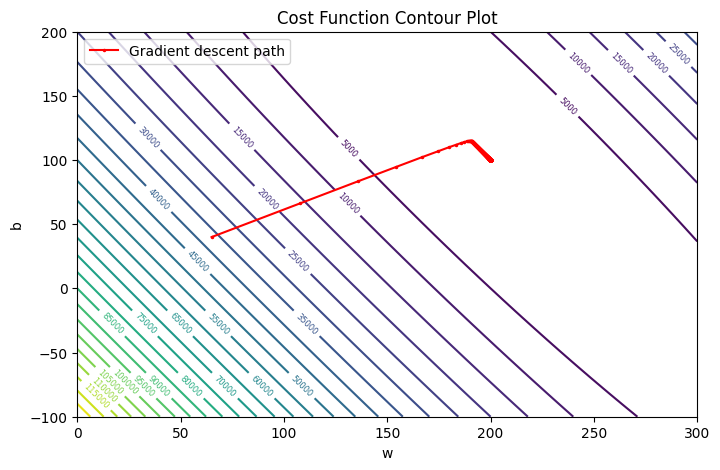

In [ ]:
# Extract from params
w_history, b_history = zip(*params[3])

# Use better ranges around the actual optimum
w_range = np.linspace(0, 300, 100)
b_range = np.linspace(-100, 200, 100)
W, B = np.meshgrid(w_range, b_range)

Z = np.zeros_like(W)
for i in range(W.shape[0]):
    for j in range(W.shape[1]):
        Z[i, j] = compute_cost(W[i, j], B[i, j], x_train, y_train) # countour plot needs Z as cost for each (w,b) pair

# Plot
plt.figure(figsize=(8, 5))
contour = plt.contour(W, B, Z, levels=25, cmap='viridis')
plt.clabel(contour, inline=True, fontsize=6)
plt.plot(w_history, b_history, 'r.-', markersize=3, label='Gradient descent path')
plt.xlabel('w')
plt.ylabel('b')
plt.title('Cost Function Contour Plot')
plt.legend()
plt.show()